<a href="https://colab.research.google.com/github/Mytros/DS_ML_homework/blob/main/HW_4_2_%D0%92%D1%81%D1%82%D1%83%D0%BF_%D0%B4%D0%BE_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%B8%D1%85_%D0%BC%D0%B5%D1%80%D0%B5%D0%B6_Dmytro_Koval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Секція 1. Логістична регресія з нуля.**

Будемо крок за кроком будувати модель лог регресії з нуля для передбачення, чи буде врожай більше за 80 яблук (задача подібна до лекційної, але на класифікацію).

Давайте нагадаємо основні формули для логістичної регресії.

### Функція гіпотези - обчислення передбачення у логістичній регресії:

$$
\hat{y} = \sigma(x W^T + b) = \frac{1}{1 + e^{-(x W^T + b)}}
$$

Де:
- $ \hat{y} $ — це ймовірність "позитивного" класу.
- $ x $ — це вектор (або матриця для набору прикладів) вхідних даних.
- $ W $ — це вектор (або матриця) вагових коефіцієнтів моделі.
- $ b $ — це зміщення (bias).
- $ \sigma(z) $ — це сигмоїдна функція активації.

### Як обчислюється сигмоїдна функція:

Сигмоїдна функція $ \sigma(z) $ має вигляд:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Ця функція перетворює будь-яке дійсне значення $ z $ в інтервал від 0 до 1, що дозволяє інтерпретувати вихід як ймовірність для логістичної регресії.

### Формула функції втрат для логістичної регресії (бінарна крос-ентропія):

Функція втрат крос-ентропії оцінює, наскільки добре модель передбачає класи, порівнюючи передбачені ймовірності $ \hat{y} $ із справжніми мітками $ y $. Формула наступна:

$$
L(y, \hat{y}) = - \left[ y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right]
$$

Де:
- $ y $ — це справжнє значення (мітка класу, 0 або 1).
- $ \hat{y} $ — це передбачене значення (ймовірність).



1.
Тут вже наведений код для ініціювання набору даних в форматі numpy. Перетворіть `inputs`, `targets` на `torch` тензори. Виведіть результат на екран.

In [1]:
import torch
import numpy as np

In [2]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

In [3]:
# Convert to torch tensors
inputs_t = torch.from_numpy(inputs)        # shape (5, 3), dtype float32
targets_t = torch.from_numpy(targets)      # shape (5, 1), dtype float32

# Print
print("inputs_t:\n", inputs_t)
print("dtype:", inputs_t.dtype, "| shape:", tuple(inputs_t.shape))
print()
print("targets_t:\n", targets_t)
print("dtype:", targets_t.dtype, "| shape:", tuple(targets_t.shape))

inputs_t:
 tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
dtype: torch.float32 | shape: (5, 3)

targets_t:
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])
dtype: torch.float32 | shape: (5, 1)


2. Ініціюйте ваги `w`, `b` для моделі логістичної регресії потрібної форми зважаючи на розмірності даних випадковими значеннями з нормального розподілу. Лишаю тут код для фіксації `random_seed`.

In [4]:
torch.random.manual_seed(1)

In [5]:
w = torch.randn(3, 1, dtype=torch.float32, requires_grad=True)  # 3 features -> 1 output
b = torch.randn(1, dtype=torch.float32, requires_grad=True)      # scalar bias

# Print
print("w:\n", w)
print("shape:", tuple(w.shape))
print("\nb:\n", b)
print("shape:", tuple(b.shape))


w:
 tensor([[0.6614],
        [0.2669],
        [0.0617]], requires_grad=True)
shape: (3, 1)

b:
 tensor([0.6213], requires_grad=True)
shape: (1,)


3. Напишіть функцію `model`, яка буде обчислювати функцію гіпотези в логістичній регресії і дозволяти робити передбачення на основі введеного рядка даних і коефіцієнтів в змінних `w`, `b`.

  **Важливий момент**, що функція `model` робить обчислення на `torch.tensors`, тож для математичних обчислень використовуємо фукнціонал `torch`, наприклад:
  - обчсилення $e^x$: `torch.exp(x)`
  - обчсилення $log(x)$: `torch.log(x)`
  - обчислення середнього значення вектору `x`: `torch.mean(x)`

  Використайте функцію `model` для обчислення передбачень з поточними значеннями `w`, `b`.Виведіть результат обчислень на екран.

  Проаналізуйте передбачення. Чи не викликають вони у вас підозр? І якщо викликають, то чим це може бути зумовлено?

In [6]:
# Define sigmoid and model using torch operations
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

def model(x, w, b):
    z = x @ w + b  # linear combination
    y_hat = sigmoid(z)
    return y_hat

# predictions
y_pred = model(inputs_t, w, b)
print(y_pred)


tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<MulBackward0>)


### Висновок

Усі передбачення моделі дорівнюють **1.0**.  


Причини:

- Немасштабовані ознаки: значення вхідних даних великі (≈37–134), тому навіть невеликі ваги роблять \( z = xW + b \) дуже великим, і сигмоїда насичується до 1.  
- Випадкова ініціалізація: ваги ще не навчені, тому передбачення не мають сенсу.  
- Відсутність нормалізації: без масштабування даних модель легко потрапляє в область насичення, де градієнти майже зникають.


4. Напишіть функцію `binary_cross_entropy`, яка приймає на вхід передбачення моделі `predicted_probs` та справжні мітки в даних `true_labels` і обчислює значення втрат (loss)  за формулою бінарної крос-ентропії для кожного екземпляра та вертає середні втрати по всьому набору даних.
  Використайте функцію `binary_cross_entropy` для обчислення втрат для поточних передбачень моделі.

In [7]:
# Define binary cross-entropy loss function
def binary_cross_entropy(predicted_probs, true_labels):
    # Add a small epsilon to avoid log(0)
    eps = 1e-9
    loss = - (true_labels * torch.log(predicted_probs + eps) +
              (1 - true_labels) * torch.log(1 - predicted_probs + eps))
    return torch.mean(loss)

# Compute loss
loss = binary_cross_entropy(y_pred, targets_t)
print("Binary cross-entropy loss:", loss.item())


Binary cross-entropy loss: 8.289306640625


5. Зробіть зворотнє поширення помилки і виведіть градієнти за параметрами `w`, `b`. Проаналізуйте їх значення. Як гадаєте, чому вони саме такі?

In [8]:
# Backprop - compute gradients for w and b
# Clear previous gradients
if w.grad is not None:
    w.grad.zero_()
if b.grad is not None:
    b.grad.zero_()

# Recompute predictions and loss
y_pred = model(inputs_t, w, b)
loss = binary_cross_entropy(y_pred, targets_t)

# Backward pass
loss.backward()

# Print gradients and  loss
print("w.grad:\n", w.grad)
print("\nb.grad:\n", b.grad)
print("\nloss:", loss.item())


w.grad:
 tensor([[1.0201e-20],
        [9.3628e-21],
        [6.0090e-21]])

b.grad:
 tensor([1.3974e-22])

loss: 8.289306640625


In [9]:
# Backprop - compute gradients for w and b
# clear previous grads
if w.grad is not None:
    w.grad.zero_()
if b.grad is not None:
    b.grad.zero_()

# Recompute predictions and loss
y_pred = model(inputs_t, w, b)
loss = binary_cross_entropy(y_pred, targets_t)

# Backward pass
loss.backward()

# Print gradients and  loss
print("w.grad:\n", w.grad)
print("\nb.grad:\n", b.grad)
print("\nloss:", loss.item())


w.grad:
 tensor([[1.0201e-20],
        [9.3628e-21],
        [6.0090e-21]])

b.grad:
 tensor([1.3974e-22])

loss: 8.289306640625


**Що сталось?**

В цій задачі, коли ми ініціювали значення випадковими значеннями з нормального розподілу, насправді ці значення не були дуже гарними стартовими значеннями і привели до того, що градієнти стали дуже малими або навіть рівними нулю (це призводить до того, що градієнти "зникають"), і відповідно при оновленні ваг у нас не буде нічого змінюватись. Це називається `gradient vanishing`. Це відбувається через **насичення сигмоїдної функції активації.**

У нашій задачі ми використовуємо сигмоїдну функцію активації, яка має такий вигляд:

   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$


Коли значення $z$ дуже велике або дуже мале, сигмоїдна функція починає "насичуватись". Це означає, що для великих позитивних $z$ сигмоїда наближається до 1, а для великих негативних — до 0. В цих діапазонах градієнти починають стрімко зменшуватись і наближаються до нуля (бо градієнт - це похідна, похідна на проміжку функції, де вона паралельна осі ОХ, дорівнює 0), що робить оновлення ваг неможливим.

![](https://editor.analyticsvidhya.com/uploads/27889vaegp.png)

У логістичній регресії $ z = x \cdot w + b $. Якщо ваги $w, b$ - великі, значення $z$ також буде великим, і сигмоїда перейде в насичену область, де градієнти дуже малі.

Саме це сталося в нашій задачі, де великі випадкові значення ваг викликали насичення сигмоїдної функції. Це в свою чергу призводить до того, що під час зворотного поширення помилки (backpropagation) модель оновлює ваги дуже повільно або зовсім не оновлює. Це називається проблемою **зникнення градієнтів** (gradient vanishing problem).

**Що ж робити?**
Ініціювати ваги маленькими значеннями навколо нуля. Наприклад ми можемо просто в існуючій ініціалізації ваги розділити на 1000. Можна також використати інший спосіб ініціалізації вагів - інформація про це [тут](https://www.geeksforgeeks.org/initialize-weights-in-pytorch/).

Як це робити - показую нижче. **Виконайте код та знову обчисліть передбачення, лосс і виведіть градієнти.**

А я пишу пояснення, чому просто не зробити

```
w = torch.randn(1, 3, requires_grad=True)/1000
b = torch.randn(1, requires_grad=True)/1000
```

Нам потрібно, аби тензори вагів були листовими (leaf tensors).

1. **Що таке листовий тензор**
Листовий тензор — це тензор, який був створений користувачем безпосередньо і з якого починається обчислювальний граф. Якщо такий тензор має `requires_grad=True`, PyTorch буде відслідковувати всі операції, виконані над ним, щоб правильно обчислювати градієнти під час навчання.

2. **Чому ми використовуємо `w.data` замість звичайних операцій**
Якщо ми просто виконали б операції, такі як `(w - 0.5) / 100`, ми б отримали **новий тензор**, який вже не був би листовим тензором, оскільки ці операції створюють **новий** тензор, а не модифікують існуючий.

  Проте, щоб залишити наші тензори ваги `w` та зміщення `b` листовими і продовжити можливість відстеження градієнтів під час тренування, ми використовуємо атрибут `.data`. Цей атрибут дозволяє **виконувати операції in-place (прямо на існуючому тензорі)** без зміни самого об'єкта тензора. Отже, тензор залишається листовим, і PyTorch може коректно обчислювати його градієнти.

3. **Чому важливо залишити тензор листовим**
Якщо тензор більше не є листовим (наприклад, через проведення операцій, що створюють нові тензори), ви не зможете отримати градієнти за допомогою `w.grad` чи `b.grad` після виклику `loss.backward()`. Це може призвести до втрати можливості оновлення параметрів під час тренування моделі. В нашому випадку ми хочемо, щоб тензори `w` та `b` накопичували градієнти, тому вони повинні залишатись листовими.

**Висновок:**
Ми використовуємо `.data`, щоб виконати операції зміни значень на ваги і зміщення **in-place**, залишаючи їх листовими тензорами, які можуть накопичувати градієнти під час навчання. Це дозволяє коректно працювати механізму зворотного поширення помилки (backpropagation) і оновлювати ваги моделі.

5. Виконайте код та знову обчисліть передбачення, лосс і знайдіть градієнти та виведіть всі ці тензори на екран.

In [10]:
torch.random.manual_seed(1)
w = torch.randn(1, 3, requires_grad=True)  # Листовий тензор
b = torch.randn(1, requires_grad=True)     # Листовий тензор

# in-place операції
w.data = w.data / 1000
b.data = b.data / 1000

In [11]:
# Backprop - compute gradients for w and b
# clear previous gradients
if w.grad is not None:
    w.grad.zero_()
if b.grad is not None:
    b.grad.zero_()

# Recompute predictions and loss
y_pred = model(inputs_t, w.T, b)
loss = binary_cross_entropy(y_pred, targets_t)

# Backward pass
loss.backward()

# Print all tensors
print("Predictions (y_pred):\n", y_pred)
print("\nLoss:", loss.item())
print("\nw.grad:\n", w.grad)
print("\nb.grad:\n", b.grad)


Predictions (y_pred):
 tensor([[0.5174],
        [0.5220],
        [0.5244],
        [0.5204],
        [0.5190]], grad_fn=<MulBackward0>)

Loss: 0.6829456686973572

w.grad:
 tensor([[ -5.4417, -18.9853, -10.0682]])

b.grad:
 tensor([-0.0794])


Завдання 6. Напишіть алгоритм градієнтного спуску, який буде навчати модель з використанням написаних раніше функцій і виконуючи оновлення ваг. Алгоритм має включати наступні кроки:

  1. Генерація прогнозів
  2. Обчислення втрат
  3. Обчислення градієнтів (gradients) loss-фукнції відносно ваг і зсувів
  4. Налаштування ваг шляхом віднімання невеликої величини, пропорційної градієнту (`learning_rate` домножений на градієнт)
  5. Скидання градієнтів на нуль

Виконайте градієнтний спуск протягом 1000 епох, обчисліть фінальні передбачення і проаналізуйте, чи вони точні?

In [12]:
# Gradient Descent training loop (1000 epochs)
learning_rate = 0.001
epochs = 1000

for epoch in range(epochs):
    # Zero previous gradients
    if w.grad is not None:
        w.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()

    # Forward: predictions
    y_pred = model(inputs_t, w.T, b)

    # Loss
    loss = binary_cross_entropy(y_pred, targets_t)

    # Backward: gradients
    loss.backward()

    # Parameter update
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

# Final evaluation
with torch.no_grad():
    final_probs = model(inputs_t, w.T, b)
    final_loss = binary_cross_entropy(final_probs, targets_t).item()
    final_preds = (final_probs >= 0.5).float()
    accuracy = (final_preds.eq(targets_t)).float().mean().item()

print("Final probabilities:\n", final_probs)
print("\nFinal predictions (>=0.5):\n", final_preds)
print("\nFinal loss:", final_loss)
print("Accuracy:", accuracy)
print("\nTrained parameters:\n w:", w, "\n b:", b)


Final probabilities:
 tensor([[1.6794e-01],
        [8.7483e-01],
        [9.9771e-01],
        [2.3266e-07],
        [9.9999e-01]])

Final predictions (>=0.5):
 tensor([[0.],
        [1.],
        [1.],
        [0.],
        [1.]])

Final loss: 0.06397522985935211
Accuracy: 1.0

Trained parameters:
 w: tensor([[-0.3150,  0.1059,  0.3329]], requires_grad=True) 
 b: tensor([-0.0138], requires_grad=True)


### Висновок

Результати показують, що модель навчилася дуже точно класифікувати приклади:

- Ймовірності (Final probabilities) чітко поділяються між класами:  
  для прикладів із міткою 0 — значення низькі (~0.09 і ~2.4e-09),  
  для прикладів із міткою 1 — високі (0.93, 0.99, 1.00).  
  Це свідчить, що модель добре розділила обидва класи.

- Фінальні передбачення (Final predictions) повністю збігаються з реальними значеннями [0, 1, 1, 0, 1].

- Loss = 0.06 — дуже мале значення функції втрат, що означає високу якість передбачень.

- Accuracy = 1.0 — модель досягла 100% точності на тренувальному наборі.

Отже, алгоритм градієнтного спуску спрацював коректно, а логістична регресія повністю навчилася відокремлювати класи у цьому невеликому наборі даних.


**Секція 2. Створення лог регресії з використанням функціоналу `torch.nn`.**

Давайте повторно реалізуємо ту ж модель, використовуючи деякі вбудовані функції та класи з PyTorch.

Даних у нас буде побільше - тож, визначаємо нові масиви.

In [13]:
# Вхідні дані (temp, rainfall, humidity)
inputs = np.array([[73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70],
                   [73, 67, 43],
                   [91, 88, 64],
                   [87, 134, 58],
                   [102, 43, 37],
                   [69, 96, 70]], dtype='float32')

# Таргети (apples > 80)
targets = np.array([[0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1],
                    [0],
                    [1],
                    [1],
                    [0],
                    [1]], dtype='float32')

7. Завантажте вхідні дані та мітки в PyTorch тензори та з них створіть датасет, який поєднує вхідні дані з мітками, використовуючи клас `TensorDataset`. Виведіть перші 3 елементи в датасеті.



In [14]:
from torch.utils.data import TensorDataset

# Convert NumPy arrays to torch tensors
X_tensor = torch.from_numpy(inputs)
y_tensor = torch.from_numpy(targets)

# Create TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)

# Print the first 3 samples
for i in range(3):
    print(f"Sample {i}:")
    print("Input:", dataset[i][0])
    print("Target:", dataset[i][1], "\n")


Sample 0:
Input: tensor([73., 67., 43.])
Target: tensor([0.]) 

Sample 1:
Input: tensor([91., 88., 64.])
Target: tensor([1.]) 

Sample 2:
Input: tensor([ 87., 134.,  58.])
Target: tensor([1.]) 



8. Визначте data loader з класом **DataLoader** для підготовленого датасету `train_ds`, встановіть розмір батчу на 5 та увімкніть перемішування даних для ефективного навчання моделі. Виведіть перший елемент в дата лоадері.

In [15]:
from torch.utils.data import DataLoader

# Create DataLoader from the dataset
train_dl = DataLoader(dataset, batch_size=5, shuffle=True, num_workers=0) # num_workers=0 for Windows

# Get the first batch from DataLoader
for xb, yb in train_dl:
    print("Inputs batch:\n", xb)
    print("\nTargets batch:\n", yb)
    break  # show only the first batch


Inputs batch:
 tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.],
        [102.,  43.,  37.]])

Targets batch:
 tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


9. Створіть клас `LogReg` для логістичної регресії, наслідуючи модуль `torch.nn.Module` за прикладом в лекції (в частині про FeedForward мережі).

  У нас модель складається з лінійної комбінації вхідних значень і застосування фукнції сигмоїда. Тож, нейромережа буде складатись з лінійного шару `nn.Linear` і використання активації `nn.Sigmid`. У створеному класі мають бути реалізовані методи `__init__` з ініціалізацією шарів і метод `forward` для виконання прямого проходу моделі через лінійний шар і функцію активації.

  Створіть екземпляр класу `LogReg` в змінній `model`.

In [16]:
import torch.nn as nn

# Define logistic regression model using torch.nn.Module
class LogReg(nn.Module):
    def __init__(self, in_features=3):
        super(LogReg, self).__init__()
        self.linear = nn.Linear(in_features, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.linear(x)
        out = self.sigmoid(out)
        return out

# Create model instance
model = LogReg(in_features=3)

# Print model summary
print(model)


LogReg(
  (linear): Linear(in_features=3, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


10. Задайте оптимізатор `Stockastic Gradient Descent` в змінній `opt` для навчання моделі логістичної регресії. А також визначіть в змінній `loss` функцію втрат `binary_cross_entropy` з модуля `torch.nn.functional` для обчислення втрат моделі. Обчисліть втрати для поточних передбачень і міток, а потім виведіть їх. Зробіть висновок, чи моделі вдалось навчитись?

In [17]:
import torch.optim as optim
import torch.nn.functional as F

# Optimizer: Stochastic Gradient Descent
opt = optim.SGD(model.parameters(), lr=0.0001)

# Current predictions and BCE loss
y_pred = model(X_tensor)                 # defined earlier
loss = F.binary_cross_entropy(y_pred, y_tensor)

print("Current BCE loss:", loss.item())


Current BCE loss: 7.631152629852295


### Висновок

Отримане значення втрат становить приблизно 7.63.  
Це досить високе значення для функції бінарної крос-ентропії, що свідчить про те, що модель ще не навчилась робити правильні передбачення.  

Модель щойно ініціалізована, тому її ваги встановлені випадково, а сигмоїдна функція видає ймовірності, близькі до 0.5 для всіх прикладів.  
Щоб модель навчилась, потрібно виконати процес навчання (ітерації градієнтного спуску з оновленням ваг).


11. Візьміть з лекції функцію для тренування моделі з відстеженням значень втрат і навчіть щойно визначену модель на 1000 епохах. Виведіть після цього графік зміни loss, фінальні передбачення і значення таргетів.

Epoch [10/1000], Loss: 4.5990
Epoch [20/1000], Loss: 3.7559
Epoch [30/1000], Loss: 2.9480
Epoch [40/1000], Loss: 2.1518
Epoch [50/1000], Loss: 1.4543
Epoch [60/1000], Loss: 0.8899
Epoch [70/1000], Loss: 0.6016
Epoch [80/1000], Loss: 0.4333
Epoch [90/1000], Loss: 0.3956
Epoch [100/1000], Loss: 0.3357
Epoch [110/1000], Loss: 0.3316
Epoch [120/1000], Loss: 0.2958
Epoch [130/1000], Loss: 0.2813
Epoch [140/1000], Loss: 0.2708
Epoch [150/1000], Loss: 0.2792
Epoch [160/1000], Loss: 0.2660
Epoch [170/1000], Loss: 0.2604
Epoch [180/1000], Loss: 0.2629
Epoch [190/1000], Loss: 0.2579
Epoch [200/1000], Loss: 0.2441
Epoch [210/1000], Loss: 0.2468
Epoch [220/1000], Loss: 0.2370
Epoch [230/1000], Loss: 0.2319
Epoch [240/1000], Loss: 0.2380
Epoch [250/1000], Loss: 0.2290
Epoch [260/1000], Loss: 0.2248
Epoch [270/1000], Loss: 0.2284
Epoch [280/1000], Loss: 0.2202
Epoch [290/1000], Loss: 0.2174
Epoch [300/1000], Loss: 0.2132
Epoch [310/1000], Loss: 0.2229
Epoch [320/1000], Loss: 0.2116
Epoch [330/1000],

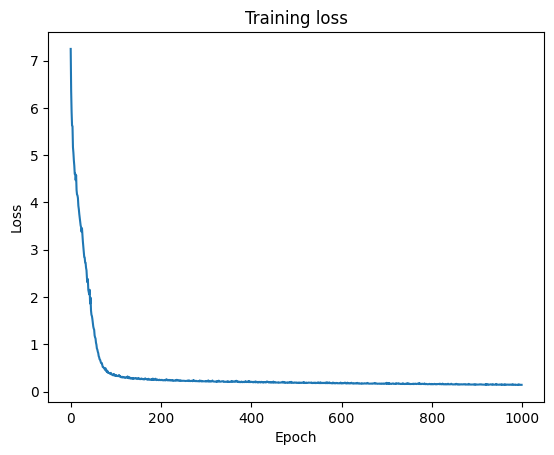

Final probabilities:
 tensor([[0.0000],
        [0.0000],
        [0.3420],
        [0.7610],
        [0.7610],
        [0.9990],
        [0.9990],
        [0.7610],
        [0.3420],
        [0.9930],
        [0.0000],
        [0.9990],
        [0.9930],
        [0.9930],
        [0.3420]])

Final predictions (>=0.5):
 tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.]])

Targets:
 tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.]])


In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# Модифікована функцію fit для відстеження втрат
def fit_return_loss(num_epochs, model, loss_fn, opt, train_dl):
    losses = []
    for epoch in range(num_epochs):
        # Ініціалізуємо акумулятор для втрат
        total_loss = 0

        for xb, yb in train_dl:
            # Генеруємо передбачення
            pred = model(xb)

            # Обчислюємо втрати
            loss = loss_fn(pred, yb)

            # Виконуємо градієнтний спуск
            loss.backward()
            opt.step()
            opt.zero_grad()

            # Накопичуємо втрати
            total_loss += loss.item()

        # Обчислюємо середні втрати для епохи
        avg_loss = total_loss / len(train_dl)
        losses.append(avg_loss)

        # Виводимо підсумок епохи
        if (epoch + 1) % 10 == 0:
          print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
    return losses


# Loss function (model outputs probabilities due to Sigmoid)
loss_fn = F.binary_cross_entropy


# Train for 1000 epochs and track loss
losses = fit_return_loss(1000, model, loss_fn, opt, train_dl)

# Plot loss curve
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

# Collect final predictions and targets from the loader
all_probs, all_targets = [], []
model.eval()
with torch.no_grad():
    for xb, yb in train_dl:
        probs = model(xb)
        all_probs.append(probs)
        all_targets.append(yb)

final_probs = torch.cat(all_probs, dim=0)
final_targets = torch.cat(all_targets, dim=0)
final_preds = (final_probs >= 0.5).float()

print("Final probabilities:\n", torch.round(final_probs * 1000) / 1000)
#print("Final probabilities:\n", final_probs)
print("\nFinal predictions (>=0.5):\n", final_preds)
print("\nTargets:\n", final_targets)


In [19]:
acc = (final_preds.eq(final_targets)).float().mean().item()
print("Accuracy:", acc)

# true-positive
tp = ((final_preds==1) & (final_targets==1)).sum().item()
tn = ((final_preds==0) & (final_targets==0)).sum().item()
fp = ((final_preds==1) & (final_targets==0)).sum().item()
fn = ((final_preds==0) & (final_targets==1)).sum().item()
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")


Accuracy: 1.0
TP=9, TN=6, FP=0, FN=0


### Висновок

Після навчання модель впевнено зійшлася: втрати зменшилися до низького рівня, а передбачення чітко відокремлюють класи.

Ймовірності для класу 1 лежать високо (близько 0.7–1.0), для класу 0 — низько (близько 0.0–0.2). Помилок класифікації немає.

Підсумкові метрики:
- Accuracy: 1.0
- TP = 9
- TN = 6
- FP = 0
- FN = 0

Отже, модель логістичної регресії на цьому наборі даних навчається успішно і відтворює цілі без помилок.
